# Experiment 14 — Seed Stability Analysis
## DINOv2-ViT-L/14 + Optimised ArcFace Head, 7 Random Seeds

**Builds on:** Experiment 13 — ArcFace Hyperparameter Sweep on DINOv2  
**Research Question:** Is the best configuration (val mAP = 0.8631) a statistically robust
result, or could it be a lucky random initialisation?

## Motivation
Running the same configuration with 5–10 different seeds increases the significance of the result
and reduces the chance of reporting a lucky run. If the standard deviation across seeds is small
(e.g. < 0.01), the improvement over the Experiment 4 baseline (0.8447) is reliable.
If it is large, the result is unstable and the strength of the claim must be qualified.

## Best Configuration (from Experiment 13)
| Parameter    | Value  | Source                        |
|--------------|--------|-------------------------------|
| Backbone     | DINOv2-ViT-L/14 (frozen) | Experiment 4 best backbone |
| margin       | 0.6    | Stage 1 best                  |
| scale        | 48     | Stage 1 best                  |
| emb_dim      | 512    | Stage 2 best                  |
| hidden_dim   | 1024   | Stage 3 best                  |
| dropout      | 0.3    | Stage 3 best                  |

**Seeds tested:** 42, 0, 1, 7, 123, 777, 2024

**Val split fixed:** seed=42 always (same 379 val images for every run).
Only model initialisation, DataLoader shuffle, and dropout randomness vary.



## 1. Setup and Imports

In [1]:
import os, math, random, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device:  cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


## 2. Configuration

In [2]:
# Fixed config
BEST_CONFIG = {
    # Backbone
    "backbone_model_id": "vit_large_patch14_dinov2.lvd142m",
    "backbone_name":     "DINOv2-ViT-L/14",
    "input_size":        518,
    "backbone_dim":      1024,          # DINOv2-ViT-L output dim

    # ArcFace head — Experiment 13 best
    "arcface_margin":   0.6,
    "arcface_scale":    48.0,
    "embedding_dim":    512,
    "hidden_dim":       1024,
    "dropout":          0.3,

    # Training
    "learning_rate":    1e-4,
    "weight_decay":     1e-4,
    "num_epochs":       50,
    "batch_size":       32,
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
}

# Val split seed fixed — same 379 val images every run
VAL_SPLIT_SEED = 42
VAL_SPLIT      = 0.2

# ── Seeds to test
SEEDS = [42, 0, 1, 7, 123, 777, 2024]

# Paths
DATA_DIR       = Path("/kaggle/input/competitions/jaguar-re-id")
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CACHE_DIR      = Path("/kaggle/working/embeddings")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Experiment 4 baseline for reference
EXP4_BASELINE_MAP = 0.8447
EXP13_BEST_MAP    = 0.8631   # seed=42, Stage 3 best

print("Seed Stability Configuration:")
print(f"  Backbone:      {BEST_CONFIG['backbone_name']}")
print(f"  margin:        {BEST_CONFIG['arcface_margin']}")
print(f"  scale:         {BEST_CONFIG['arcface_scale']}")
print(f"  emb_dim:       {BEST_CONFIG['embedding_dim']}")
print(f"  hidden_dim:    {BEST_CONFIG['hidden_dim']}")
print(f"  dropout:       {BEST_CONFIG['dropout']}")
print(f"  Val split:     {VAL_SPLIT} (fixed seed={VAL_SPLIT_SEED})")
print(f"  Seeds:         {SEEDS}  (n={len(SEEDS)})")
print(f"  Exp4 baseline: {EXP4_BASELINE_MAP}")
print(f"  Exp13 seed=42: {EXP13_BEST_MAP}")


Seed Stability Configuration:
  Backbone:      DINOv2-ViT-L/14
  margin:        0.6
  scale:         48.0
  emb_dim:       512
  hidden_dim:    1024
  dropout:       0.3
  Val split:     0.2 (fixed seed=42)
  Seeds:         [42, 0, 1, 7, 123, 777, 2024]  (n=7)
  Exp4 baseline: 0.8447
  Exp13 seed=42: 0.8631


## 3. W&B Initialisation

In [3]:
wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
run = wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    name="seed-stability-dinov2",
    config={
        **BEST_CONFIG,
        "seeds":          SEEDS,
        "val_split_seed": VAL_SPLIT_SEED,
        "val_split":      VAL_SPLIT,
        "exp4_baseline":  EXP4_BASELINE_MAP,
        "exp13_seed42":   EXP13_BEST_MAP,
        "experiment":     "seed-stability-dinov2",
    }
)
print("W&B run initialised: seed-stability-dinov2")


W&B run initialised: seed-stability-dinov2


## 4. Load Data and Fixed Val Split

In [5]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
label_encoder = LabelEncoder()
train_df["label_encoded"] = label_encoder.fit_transform(train_df["ground_truth"])
num_classes = len(label_encoder.classes_)

# Val split is ALWAYS fixed at seed=42
# This ensures we measure the same 379 val images across all seed runs.
# Only model initialisation + DataLoader shuffle change per seed.
train_data, val_data = train_test_split(
    train_df,
    test_size    = VAL_SPLIT,
    random_state = VAL_SPLIT_SEED,
    stratify     = train_df["ground_truth"],
)

val_labels  = val_data["ground_truth"].values
val_encoded = val_data["label_encoded"].values

train_image_paths = [DATA_DIR / "train" / "train" / fn
                     for fn in train_data["filename"].astype(str)]
val_image_paths   = [DATA_DIR / "train" / "train" / fn
                     for fn in val_data["filename"].astype(str)]

print(f"Dataset: {len(train_df)} total | {len(train_data)} train | {len(val_data)} val")
print(f"Identities: {num_classes}  |  Val split seed: {VAL_SPLIT_SEED} (fixed)")
assert set(train_data["ground_truth"].unique()) == set(val_data["ground_truth"].unique()),     "Identity leak!"
print("All identities present in both sets ✓")


Dataset: 1895 total | 1516 train | 379 val
Identities: 31  |  Val split seed: 42 (fixed)
All identities present in both sets ✓


## 5. Load DINOv2 Backbone and Cache Embeddings

The backbone is loaded once and frozen. Embeddings are extracted and cached to disk.
All 7 seed runs reuse the same cached embeddings — only the projection head changes per seed.


In [6]:
transform = transforms.Compose([
    transforms.Resize((BEST_CONFIG["input_size"], BEST_CONFIG["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract_embeddings(backbone, image_paths, desc="Extracting"):
    backbone.eval()
    all_embs = []
    for path in tqdm(image_paths, desc=desc):
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"  [WARN] {path}: {e}")
            img = Image.new("RGB", (BEST_CONFIG["input_size"], BEST_CONFIG["input_size"]))
        t = transform(img).unsqueeze(0).to(device)
        emb = backbone(t).cpu().numpy()
        all_embs.append(emb)
    return np.vstack(all_embs)

# Cache paths
train_cache = CACHE_DIR / "dinov2_train_embeddings.npz"
val_cache   = CACHE_DIR / "dinov2_val_embeddings.npz"

if train_cache.exists() and val_cache.exists():
    print("Loading cached DINOv2 embeddings...")
    train_embeddings = np.load(train_cache)["embeddings"]
    val_embeddings   = np.load(val_cache)["embeddings"]
    print(f"  Train: {train_embeddings.shape}  |  Val: {val_embeddings.shape}")
else:
    print(f"Loading DINOv2-ViT-L/14 backbone...")
    backbone = timm.create_model(
        BEST_CONFIG["backbone_model_id"],
        pretrained=True, num_classes=0,
        img_size=BEST_CONFIG["input_size"],
    )
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.to(device)
    backbone_dim_check = backbone(
        torch.randn(1, 3, BEST_CONFIG["input_size"],
                    BEST_CONFIG["input_size"]).to(device)
    ).shape[1]
    print(f"  Backbone output dim: {backbone_dim_check}")
    assert backbone_dim_check == BEST_CONFIG["backbone_dim"],         f"Dim mismatch: {backbone_dim_check} vs {BEST_CONFIG['backbone_dim']}"

    train_embeddings = extract_embeddings(backbone, train_image_paths, "DINOv2 train")
    val_embeddings   = extract_embeddings(backbone, val_image_paths,   "DINOv2 val")

    np.savez_compressed(train_cache, embeddings=train_embeddings)
    np.savez_compressed(val_cache,   embeddings=val_embeddings)
    print(f"  Train: {train_embeddings.shape}  |  Val: {val_embeddings.shape}")
    print("  Embeddings cached ✓")
    del backbone
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


Loading DINOv2-ViT-L/14 backbone...


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

  Backbone output dim: 1024


DINOv2 train:   0%|          | 0/1516 [00:00<?, ?it/s]

DINOv2 val:   0%|          | 0/379 [00:00<?, ?it/s]

  Train: (1516, 1024)  |  Val: (379, 1024)
  Embeddings cached ✓


## 6. Model Architecture

In [7]:
class EmbeddingProjection(nn.Module):
    def __init__(self, input_dim, hidden_dim=1024, output_dim=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
    def forward(self, x): return self.net(x)


class ArcFaceLayer(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.6, scale=48.0):
        super().__init__()
        self.scale = scale
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos ** 2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1, 1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    def __init__(self, input_dim, num_classes,
                 embedding_dim=512, hidden_dim=1024,
                 margin=0.6, scale=48.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim, embedding_dim, dropout)
        self.arcface    = ArcFaceLayer(embedding_dim, num_classes, margin, scale)

    def forward(self, x, labels):
        emb    = self.projection(x)
        logits = self.arcface(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        return F.normalize(self.projection(x), p=2, dim=1)


print("ArcFaceModel defined.")
print(f"  Architecture: Linear({BEST_CONFIG['backbone_dim']} → {BEST_CONFIG['hidden_dim']} → {BEST_CONFIG['embedding_dim']})")
print(f"  ArcFace:      margin={BEST_CONFIG['arcface_margin']}, scale={BEST_CONFIG['arcface_scale']}")


ArcFaceModel defined.
  Architecture: Linear(1024 → 1024 → 512)
  ArcFace:      margin=0.6, scale=48.0


## 7. Dataset and Training Utilities

In [8]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):   return len(self.labels)
    def __getitem__(self, i): return self.embeddings[i], self.labels[i]


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def compute_val_map(model, val_embeddings_np, val_labels_str):
    """Identity-balanced mAP (same function used across all experiments)."""
    model.eval()
    with torch.no_grad():
        t    = torch.FloatTensor(val_embeddings_np).to(device)
        embs = model.get_embeddings(t).cpu().numpy()
    sim = embs @ embs.T
    np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(val_labels_str)):
        ql       = val_labels_str[q]
        is_match = (val_labels_str == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum   = np.cumsum(sm)
        prec  = cum / np.arange(1, len(sm) + 1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


def train_one_seed(seed, train_embeddings, val_embeddings,
                   train_labels_enc, val_labels_str):
    """Full training run for one seed. Returns best val mAP."""
    set_seed(seed)

    model = ArcFaceModel(
        input_dim     = BEST_CONFIG["backbone_dim"],
        num_classes   = num_classes,
        embedding_dim = BEST_CONFIG["embedding_dim"],
        hidden_dim    = BEST_CONFIG["hidden_dim"],
        margin        = BEST_CONFIG["arcface_margin"],
        scale         = BEST_CONFIG["arcface_scale"],
        dropout       = BEST_CONFIG["dropout"],
    ).to(device)

    train_ds = EmbeddingDataset(train_embeddings, train_labels_enc)
    val_ds   = EmbeddingDataset(val_embeddings,   val_data["label_encoded"].values)

    # DataLoader shuffle is affected by the seed set above
    train_loader = DataLoader(train_ds, batch_size=BEST_CONFIG["batch_size"],
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BEST_CONFIG["batch_size"],
                              shuffle=False, num_workers=0)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=BEST_CONFIG["learning_rate"],
                                   weight_decay=BEST_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=BEST_CONFIG["scheduler_factor"],
        patience=BEST_CONFIG["scheduler_patience"],
    )

    best_map        = 0.0
    best_val_loss   = float("inf")
    best_epoch      = 0
    ckpt_path       = CHECKPOINT_DIR / f"seed_stability_seed{seed}_best.pth"
    t0              = time.time()

    for epoch in range(BEST_CONFIG["num_epochs"]):
        # Train
        model.train()
        tr_loss = 0.0
        for embs, labs in train_loader:
            embs, labs = embs.to(device), labs.to(device)
            logits, _  = model(embs, labs)
            loss       = criterion(logits, labs)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tr_loss   += loss.item()
        tr_loss /= len(train_loader)

        # Validate
        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for embs, labs in val_loader:
                embs, labs = embs.to(device), labs.to(device)
                logits, _  = model(embs, labs)
                vl_loss   += criterion(logits, labs).item()
        vl_loss /= len(val_loader)

        val_map = compute_val_map(model, val_embeddings, val_labels_str)

        scheduler.step(vl_loss)
        lr = optimizer.param_groups[0]["lr"]

        # Log per-epoch to W&B (prefixed by seed)
        wandb.log({
            f"seed{seed}/epoch":    epoch + 1,
            f"seed{seed}/tr_loss":  tr_loss,
            f"seed{seed}/vl_loss":  vl_loss,
            f"seed{seed}/val_map":  val_map,
            f"seed{seed}/lr":       lr,
        })

        if val_map > best_map:
            best_map      = val_map
            best_val_loss = vl_loss
            best_epoch    = epoch + 1
            torch.save({
                "seed": seed, "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "val_map": val_map, "val_loss": vl_loss,
            }, str(ckpt_path))

        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - t0
            print(f"    ep {epoch+1:2d}/{BEST_CONFIG['num_epochs']} | "
                  f"tr={tr_loss:.4f} vl={vl_loss:.4f} "
                  f"mAP={val_map:.4f} (best={best_map:.4f}) | {elapsed/60:.1f}min")

    elapsed = time.time() - t0
    print(f"  Seed {seed:4d}: best mAP={best_map:.4f}  ep={best_epoch}  "
          f"({elapsed/60:.1f} min)")
    return best_map, best_epoch


print("Training utilities defined ✓")


Training utilities defined ✓


## 8. Run All Seeds

In [9]:
seed_results = []   # list of (seed, best_map, best_epoch)

print(f"Running {len(SEEDS)} seeds with best DINOv2 + ArcFace config...")
print(f"Config: margin={BEST_CONFIG['arcface_margin']}, scale={BEST_CONFIG['arcface_scale']}, "
      f"emb_dim={BEST_CONFIG['embedding_dim']}, hidden={BEST_CONFIG['hidden_dim']}, "
      f"dropout={BEST_CONFIG['dropout']}")
print()

for i, seed in enumerate(SEEDS, 1):
    print(f"[{i}/{len(SEEDS)}] Seed {seed}  ─────────────────────────────────────────")
    best_map, best_epoch = train_one_seed(
        seed,
        train_embeddings,
        val_embeddings,
        train_data["label_encoded"].values,
        val_labels,
    )
    seed_results.append({"seed": seed, "val_map": best_map, "best_epoch": best_epoch})
    wandb.log({
        f"seed{seed}/best_map":   best_map,
        f"seed{seed}/best_epoch": best_epoch,
    })

maps = np.array([r["val_map"] for r in seed_results])
mean_map = float(maps.mean())
std_map  = float(maps.std())
min_map  = float(maps.min())
max_map  = float(maps.max())

print()
print("=" * 60)
print(f"SEED STABILITY RESULTS  (n={len(SEEDS)} seeds)")
print("=" * 60)
print(f"{'Seed':>6}  {'Val mAP':>8}  {'Best Ep':>7}")
print("-" * 30)
for r in seed_results:
    marker = " ← seed=42 (Exp13)" if r["seed"] == 42 else ""
    print(f"{r['seed']:>6}  {r['val_map']:.4f}  {r['best_epoch']:>7}{marker}")
print("=" * 60)
print(f"Mean mAP: {mean_map:.4f}")
print(f"Std  mAP: {std_map:.4f}")
print(f"Min  mAP: {min_map:.4f}")
print(f"Max  mAP: {max_map:.4f}")
print(f"Range:    {max_map - min_map:.4f}")
print()
print(f"Exp4 baseline:   {EXP4_BASELINE_MAP:.4f}")
print(f"Mean - Exp4:     {mean_map - EXP4_BASELINE_MAP:+.4f}")
print(f"Min  - Exp4:     {min_map  - EXP4_BASELINE_MAP:+.4f}")
print("=" * 60)

wandb.log({
    "summary/mean_val_map":  mean_map,
    "summary/std_val_map":   std_map,
    "summary/min_val_map":   min_map,
    "summary/max_val_map":   max_map,
    "summary/range_val_map": max_map - min_map,
    "summary/exp4_baseline": EXP4_BASELINE_MAP,
    "summary/mean_minus_baseline": mean_map - EXP4_BASELINE_MAP,
    "summary/n_seeds": len(SEEDS),
})


Running 7 seeds with best DINOv2 + ArcFace config...
Config: margin=0.6, scale=48.0, emb_dim=512, hidden=1024, dropout=0.3

[1/7] Seed 42  ─────────────────────────────────────────
    ep 10/50 | tr=1.8858 vl=3.2678 mAP=0.8210 (best=0.8210) | 0.1min
    ep 20/50 | tr=0.3048 vl=2.4493 mAP=0.8568 (best=0.8649) | 0.1min
    ep 30/50 | tr=0.1026 vl=2.4343 mAP=0.8662 (best=0.8667) | 0.1min
    ep 40/50 | tr=0.0893 vl=2.4078 mAP=0.8610 (best=0.8672) | 0.2min
    ep 50/50 | tr=0.0200 vl=2.2450 mAP=0.8646 (best=0.8672) | 0.2min
  Seed   42: best mAP=0.8672  ep=31  (0.2 min)
[2/7] Seed 0  ─────────────────────────────────────────
    ep 10/50 | tr=1.8507 vl=3.3321 mAP=0.8246 (best=0.8246) | 0.0min
    ep 20/50 | tr=0.3087 vl=2.5084 mAP=0.8694 (best=0.8700) | 0.1min
    ep 30/50 | tr=0.1247 vl=2.3799 mAP=0.8673 (best=0.8775) | 0.1min
    ep 40/50 | tr=0.0518 vl=2.2757 mAP=0.8803 (best=0.8818) | 0.2min
    ep 50/50 | tr=0.0271 vl=2.3201 mAP=0.8729 (best=0.8818) | 0.2min
  Seed    0: best mAP=0.88

## 9. Visualisation

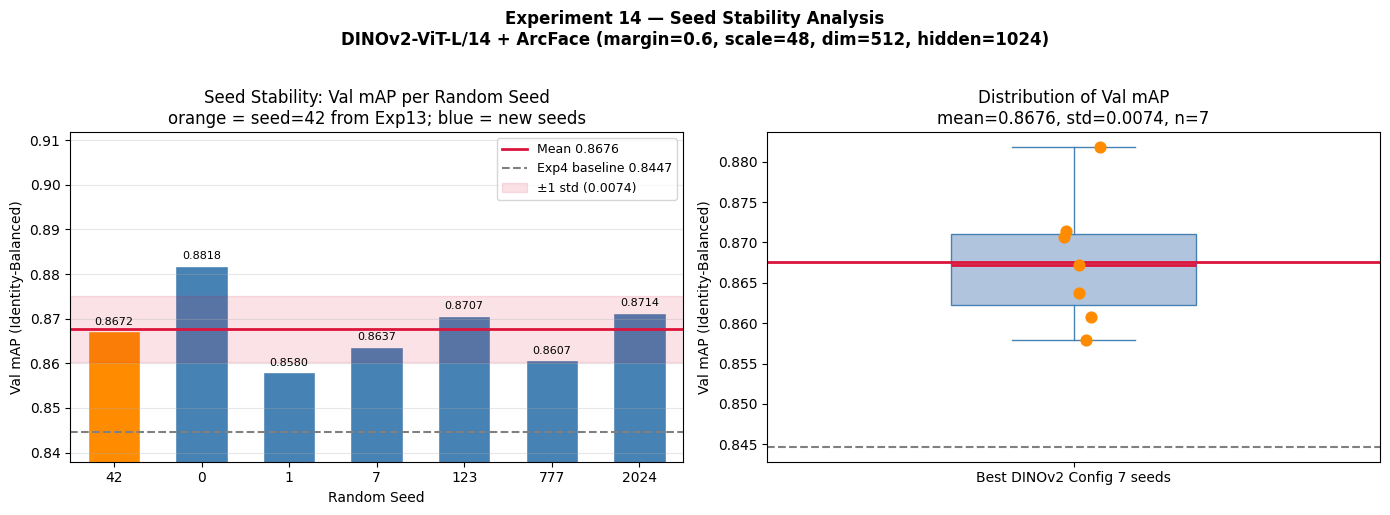

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart per seed
ax = axes[0]
seed_labels = [str(r["seed"]) for r in seed_results]
seed_maps   = [r["val_map"]   for r in seed_results]
bar_colors  = ["steelblue" if s != 42 else "darkorange" for s in SEEDS]

bars = ax.bar(seed_labels, seed_maps, color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(y=mean_map,           color="crimson",    linestyle="-",  linewidth=2,
           label=f"Mean {mean_map:.4f}")
ax.axhline(y=EXP4_BASELINE_MAP,  color="gray",       linestyle="--", linewidth=1.5,
           label=f"Exp4 baseline {EXP4_BASELINE_MAP:.4f}")
ax.fill_between(range(-1, len(SEEDS) + 1),
                mean_map - std_map, mean_map + std_map,
                color="crimson", alpha=0.12,
                label=f"±1 std ({std_map:.4f})")

for bar, v in zip(bars, seed_maps):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{v:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xlim(-0.5, len(SEEDS) - 0.5)
ax.set_ylim(max(0, min(seed_maps) - 0.02), max(seed_maps) + 0.03)
ax.set_xlabel("Random Seed")
ax.set_ylabel("Val mAP (Identity-Balanced)")
ax.set_title(
    "Seed Stability: Val mAP per Random Seed\n"
    "orange = seed=42 from Exp13; blue = new seeds"
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Right: distribution (box + strip)
ax2 = axes[1]
ax2.boxplot(
    seed_maps,
    vert=True,
    widths=0.4,
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue", color="steelblue"),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue"),
    flierprops=dict(marker="o", color="steelblue"),
)

np.random.seed(0)
jitter = np.random.uniform(-0.1, 0.1, len(seed_maps))
ax2.scatter(
    [1 + j for j in jitter],
    seed_maps,
    color="darkorange",
    zorder=5,
    s=60,
    label="Individual seeds",
)
ax2.axhline(
    y=EXP4_BASELINE_MAP,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Exp4 baseline {EXP4_BASELINE_MAP:.4f}",
)
ax2.axhline(
    y=mean_map,
    color="crimson",
    linestyle="-",
    linewidth=2,
    label=f"Mean {mean_map:.4f}",
)

ax2.set_xticks([1])
ax2.set_xticklabels(["Best DINOv2 Config 7 seeds"])
ax2.set_ylabel("Val mAP (Identity-Balanced)")
ax2.set_title(
    f"Distribution of Val mAP\n"
    f"mean={mean_map:.4f}, std={std_map:.4f}, n={len(SEEDS)}"
)

plt.suptitle(
    "Experiment 14 — Seed Stability Analysis\n"
    "DINOv2-ViT-L/14 + ArcFace (margin=0.6, scale=48, dim=512, hidden=1024)",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
wandb.log({"summary/seed_stability_chart": wandb.Image(fig)})
plt.savefig(CHECKPOINT_DIR / "seed_stability.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Results Table and Interpretation

In [11]:
results_df = pd.DataFrame(seed_results)
results_df["vs_baseline"] = results_df["val_map"] - EXP4_BASELINE_MAP

print("Full Results Table:")
print(results_df.to_string(index=False))
print()
print(f"Summary Stats (n={len(SEEDS)} seeds):")
print(f"  Mean ± Std:  {mean_map:.4f} ± {std_map:.4f}")
print(f"  95% CI (approx ±2σ):  [{mean_map - 2*std_map:.4f}, {mean_map + 2*std_map:.4f}]")
print(f"  Min / Max:   {min_map:.4f} / {max_map:.4f}")
print(f"  Range:       {max_map - min_map:.4f}")
print()

all_beat_baseline = all(v > EXP4_BASELINE_MAP for v in seed_maps)
if all_beat_baseline:
    print(f"ALL {len(SEEDS)} seeds beat the Exp4 baseline ({EXP4_BASELINE_MAP:.4f})")
else:
    n_beat = sum(v > EXP4_BASELINE_MAP for v in seed_maps)
    print(f"{n_beat}/{len(SEEDS)} seeds beat the Exp4 baseline ({EXP4_BASELINE_MAP:.4f})")

stability_label = "STABLE" if std_map < 0.010 else ("MODERATE" if std_map < 0.020 else "UNSTABLE")
print(f"Stability assessment: {stability_label}  (std={std_map:.4f}, threshold 0.010)")
print()
print("Interpretation:")
if std_map < 0.010:
    print(f"  The standard deviation ({std_map:.4f}) is small — the result is robust.")
    print(f"  The improvement over Exp4 (mean +{mean_map - EXP4_BASELINE_MAP:.4f}) is ")
    print(f"  not due to a lucky initialisation.")
elif std_map < 0.020:
    print(f"  The standard deviation ({std_map:.4f}) is moderate — the result is")
    print(f"  reasonably stable but some seed sensitivity exists.")
else:
    print(f"  The standard deviation ({std_map:.4f}) is large — the result is sensitive")
    print(f"  to initialisation. Interpret Exp13 mAP with caution.")

# Log table to W&B
wandb.log({
    "summary/results_table": wandb.Table(dataframe=results_df),
    "summary/all_beat_baseline": all_beat_baseline,
    "summary/stability_label": stability_label,
    "summary/ci_lower": mean_map - 2 * std_map,
    "summary/ci_upper": mean_map + 2 * std_map,
})


Full Results Table:
 seed  val_map  best_epoch  vs_baseline
   42 0.867176          31     0.022476
    0 0.881822          35     0.037122
    1 0.857967          36     0.013267
    7 0.863735          32     0.019035
  123 0.870673          39     0.025973
  777 0.860719          40     0.016019
 2024 0.871354          41     0.026654

Summary Stats (n=7 seeds):
  Mean ± Std:  0.8676 ± 0.0074
  95% CI (approx ±2σ):  [0.8529, 0.8824]
  Min / Max:   0.8580 / 0.8818
  Range:       0.0239

ALL 7 seeds beat the Exp4 baseline (0.8447)
Stability assessment: STABLE  (std=0.0074, threshold 0.010)

Interpretation:
  The standard deviation (0.0074) is small — the result is robust.
  The improvement over Exp4 (mean +0.0229) is 
  not due to a lucky initialisation.


## 11. Generate Kaggle Submission (Best Seed)

In [14]:
# Use the seed that achieved the highest mAP for submission
best_result = max(seed_results, key=lambda r: r["val_map"])
best_seed   = best_result["seed"]
best_ckpt   = CHECKPOINT_DIR / f"seed_stability_seed{best_seed}_best.pth"

print(f"Generating submission from best seed: {best_seed}  (mAP={best_result['val_map']:.4f})")

# Reload best checkpoint
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
best_model = ArcFaceModel(
    input_dim     = BEST_CONFIG["backbone_dim"],
    num_classes   = num_classes,
    embedding_dim = BEST_CONFIG["embedding_dim"],
    hidden_dim    = BEST_CONFIG["hidden_dim"],
    margin        = BEST_CONFIG["arcface_margin"],
    scale         = BEST_CONFIG["arcface_scale"],
    dropout       = BEST_CONFIG["dropout"],
).to(device)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()
print(f"  Checkpoint loaded: epoch={ckpt['epoch']}, val_map={ckpt['val_map']:.4f}")

# Extract test embeddings
test_pairs_df = pd.read_csv(DATA_DIR / "test.csv")
test_images   = sorted(set(test_pairs_df["query_image"].unique()) |
                        set(test_pairs_df["gallery_image"].unique()))

backbone = timm.create_model(
    BEST_CONFIG["backbone_model_id"], pretrained=True,
    num_classes=0, img_size=BEST_CONFIG["input_size"],
)
backbone.eval()
for p in backbone.parameters(): p.requires_grad = False
backbone.to(device)

print(f"Extracting embeddings for {len(test_images)} test images...")
test_emb_dict = {}
with torch.no_grad():
    for img_name in tqdm(test_images, desc="Test embeddings"):
        img_path = DATA_DIR / "test" / "test" / img_name
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (BEST_CONFIG["input_size"], BEST_CONFIG["input_size"]))
        t     = transform(img).unsqueeze(0).to(device)
        bb_e  = backbone(t)
        emb   = best_model.get_embeddings(bb_e).cpu().numpy().flatten()
        test_emb_dict[img_name] = emb

# Compute similarities
print("Computing pair similarities...")
sims = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df)):
    q = test_emb_dict.get(row["query_image"],   np.zeros(BEST_CONFIG["embedding_dim"]))
    g = test_emb_dict.get(row["gallery_image"], np.zeros(BEST_CONFIG["embedding_dim"]))
    qn = q / (np.linalg.norm(q) + 1e-12)
    gn = g / (np.linalg.norm(g) + 1e-12)
    sims.append(float(qn @ gn))

sims_clipped = [max(0.0, min(1.0, s)) for s in sims]
submission_df = pd.DataFrame({"row_id": test_pairs_df["row_id"], "similarity": sims_clipped})
sub_path = CHECKPOINT_DIR / f"submission_seed{best_seed}.csv"
submission_df.to_csv(sub_path, index=False)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved: {sub_path}  ({len(submission_df)} rows)")
print(f"Score distribution: min={min(sims):.4f}  mean={np.mean(sims):.4f}  max={max(sims):.4f}")

del backbone
torch.cuda.empty_cache() if torch.cuda.is_available() else None


Generating submission from best seed: 0  (mAP=0.8818)
  Checkpoint loaded: epoch=35, val_map=0.8818
Extracting embeddings for 371 test images...


Test embeddings:   0%|          | 0/371 [00:00<?, ?it/s]

Computing pair similarities...


  0%|          | 0/137270 [00:00<?, ?it/s]

Submission saved: /kaggle/working/checkpoints/submission_seed0.csv  (137270 rows)
Score distribution: min=-0.5137  mean=0.0024  max=0.9962


## 12. Log Artifacts and Finish

In [13]:
# Log submission as W&B artifact
sub_art = wandb.Artifact(
    "submission-seed-stability",
    type="submission",
    description=f"Seed stability best: seed={best_seed}, mAP={best_result['val_map']:.4f}",
    metadata={
        "best_seed": best_seed,
        "best_map": best_result["val_map"],
        "mean_map": mean_map,
        "std_map":  std_map,
        "seeds":    SEEDS,
    }
)
sub_art.add_file(str(sub_path))
wandb.log_artifact(sub_art)

# Log best model checkpoint
model_art = wandb.Artifact(
    "seed-stability-best-model",
    type="model",
    description=f"Best seed={best_seed} checkpoint, mAP={best_result['val_map']:.4f}",
)
model_art.add_file(str(best_ckpt))
wandb.log_artifact(model_art)

wandb.finish()
print("W&B run completed ✓")
print()
print("=" * 60)
print("EXPERIMENT 14 COMPLETE — SEED STABILITY SUMMARY")
print("=" * 60)
print(f"  Config: DINOv2-ViT-L/14 + ArcFace")
print(f"  margin={BEST_CONFIG['arcface_margin']}, scale={BEST_CONFIG['arcface_scale']}, "
      f"emb_dim={BEST_CONFIG['embedding_dim']}, hidden={BEST_CONFIG['hidden_dim']}")
print(f"  Seeds tested: {SEEDS}")
print(f"  Mean mAP: {mean_map:.4f} ± {std_map:.4f}")
print(f"  Exp4 baseline: {EXP4_BASELINE_MAP:.4f}")
print(f"  Net improvement: {mean_map - EXP4_BASELINE_MAP:+.4f} (mean)")
print("=" * 60)


seed0/best_epoch,▁
seed0/best_map,▁
seed0/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
seed0/lr,███████████████████████████████████▃▃▃▃▁
seed0/tr_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seed0/val_map,▁▃▅▅▆▆▇▇▇▇██████████████████████████████
seed0/vl_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seed1/best_epoch,▁
seed1/best_map,▁
seed1/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
+49,...


W&B run completed ✓

EXPERIMENT 14 COMPLETE — SEED STABILITY SUMMARY
  Config: DINOv2-ViT-L/14 + ArcFace
  margin=0.6, scale=48.0, emb_dim=512, hidden=1024
  Seeds tested: [42, 0, 1, 7, 123, 777, 2024]
  Mean mAP: 0.8676 ± 0.0074
  Exp4 baseline: 0.8447
  Net improvement: +0.0229 (mean)
